In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split 
from torch import nn
import torch
import torch.nn.functional
import random
import functools
import copy
from copy import deepcopy

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

data = np.load('hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros

In [3]:
def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        u_past = u[k-nb:k]
        y_past = y[k-na:k]

        # Trigonometric features of the raw angles
        sin_y = np.sin(y_past)
        cos_y = np.cos(y_past)
        
        X.append(np.concatenate([u_past,sin_y, cos_y]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

In [4]:
na = 15
nb = 15
u_tr, u_val, th_tr, th_val = train_test_split(u_train, th_train, shuffle = False)

Xtrain_u, Ytrain_u = create_IO_data(u_tr, th_tr, na, nb)
Xval_u, Yval_u = create_IO_data(u_val, th_val, na, nb)

# Scaling of variables
X_mean = np.mean(Xtrain_u, axis = 0)
X_std = np.std(Xtrain_u, axis = 0)

Y_mean = float(np.mean(Ytrain_u))
Y_std = float(np.std(Ytrain_u))

Xtrain = (Xtrain_u - X_mean)/X_std
Xval = (Xval_u - X_mean)/X_std

Ytrain = (Ytrain_u - Y_mean)/Y_std
Yval = (Yval_u - Y_mean)/Y_std

In [5]:
def simulation_IO_model(f, ulist, ylist, skip=50):

    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    
    for u in ulist[skip:]:
        u_p = np.array(upast)
        y_p = np.array(ypast)
        
        x = np.concatenate([u_p ,np.sin(y_p), np.cos(y_p)],axis=0)
        ypred = f(x)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y)

In [6]:
class Simple_net(nn.Module):
    def __init__(self,n_in, n_hidden_layer, n_nodes_per_layer, activation):
        super().__init__()
        
        if n_hidden_layer==0: #linear model
            seq = [nn.Linear(n_in,1)]
        else:
            seq = [nn.Linear(n_in,n_nodes_per_layer), activation()]
            for layer in range(n_hidden_layer-1):
                seq.extend([nn.Linear(n_nodes_per_layer,n_nodes_per_layer), activation()])
            seq.append(nn.Linear(n_nodes_per_layer,1))
        
        self.non_lin_net = nn.Sequential(*seq).double()
    
    def forward(self, x):
        return self.non_lin_net(x)[:,0]

In [7]:
def fit(net, X_data, Y_data, X_val, Y_val, epochs=5*10**3):
    optimizer = torch.optim.Adam(net.parameters())
    best_state = None
    best_loss = float('inf')
    
    for epoch in range(1,epochs+1):
        loss = torch.mean((net(X_data)-Y_data)**2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if epoch%1000==0:
            loss_val = torch.mean((net(X_val)-Y_val)**2).item()**0.5 #RMS
            if loss_val<best_loss:
                best_state = deepcopy(net.state_dict())
                best_loss = loss_val
            print(f'epoch={epoch:5}, loss={loss.item()**0.5:.2f}')
    if best_state:
        net.load_state_dict(best_state)
    return net

optimizing... {'n_hidden_layer': 1, 'n_nodes_per_layer': 64, 'activation': <class 'torch.nn.modules.activation.ELU'>}
epoch= 1000, loss=0.03
epoch= 2000, loss=0.02
epoch= 3000, loss=0.01
epoch= 4000, loss=0.01
epoch= 5000, loss=0.01
optimizing... {'n_hidden_layer': 2, 'n_nodes_per_layer': 64, 'activation': <class 'torch.nn.modules.activation.ELU'>}
epoch= 1000, loss=0.02
epoch= 2000, loss=0.01
epoch= 3000, loss=0.02
epoch= 4000, loss=0.01
epoch= 5000, loss=0.01
optimizing... {'n_hidden_layer': 3, 'n_nodes_per_layer': 64, 'activation': <class 'torch.nn.modules.activation.ELU'>}
epoch= 1000, loss=0.02
epoch= 2000, loss=0.01
epoch= 3000, loss=0.01
epoch= 4000, loss=0.01
epoch= 5000, loss=0.01
optimizing... {'n_hidden_layer': 4, 'n_nodes_per_layer': 64, 'activation': <class 'torch.nn.modules.activation.ELU'>}
epoch= 1000, loss=0.01
epoch= 2000, loss=0.01
epoch= 3000, loss=0.01
epoch= 4000, loss=0.01
epoch= 5000, loss=0.01
done with loop for option n_hidden_layer
choice=1 result=0.021772
ch

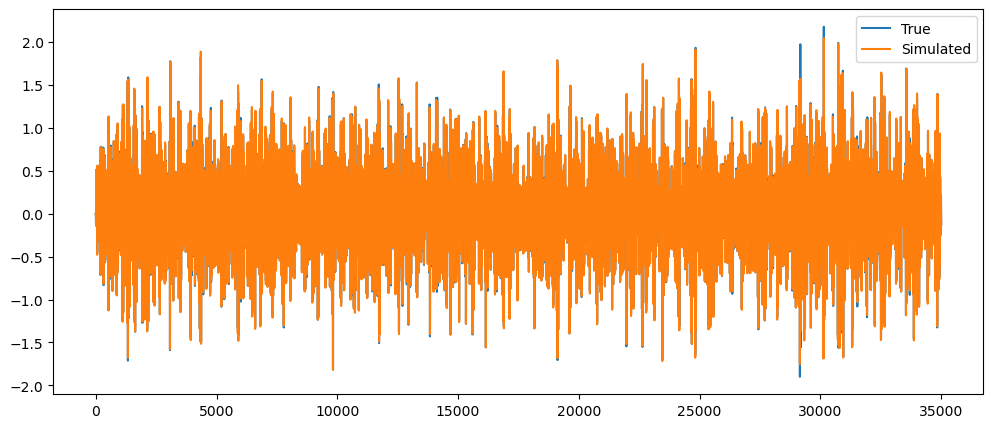

In [8]:
@functools.lru_cache(maxsize=500, typed=False)
def test(X_train, Y_train, X_val, Y_val, n_hidden_layer=2, n_nodes_per_layer=64, activation=nn.ELU):
    net = Simple_net(X_train.shape[1], n_hidden_layer, n_nodes_per_layer, activation) #a=)
    net = fit(net, X_train, Y_train, X_val, Y_val) #a=)
    RMS = torch.mean((net(X_val)-Y_val)**2).item()**0.5 #a=)
    return RMS #a=)

#a basic optimizer 
Xtrain, Ytrain, Xval, Yval = [torch.as_tensor(x).double() for x in [Xtrain, Ytrain, Xval, Yval]]
current_best = dict(n_hidden_layer=2, n_nodes_per_layer=64, activation=nn.ELU)
choices_dict = dict(n_hidden_layer=[1,2,3,4], \
               n_nodes_per_layer=[16,32,64,128,256], \
               activation=[nn.Tanh,nn.ReLU,nn.ELU,nn.Sigmoid])

for it in range(30):
    last_best = copy.deepcopy(current_best)
    
    for name, choices in choices_dict.items(): #iterate over the n_hidden_layer, n_nodes_per_layer, activation
        results = []
        for choice in choices: #check each candidate
            now = copy.deepcopy(current_best) #create a new dict
            now[name] = choice #put choice in the correct place
            print('optimizing...',now) 
            results.append(test(Xtrain, Ytrain, Xval, Yval,**now)) #add it to results

        print('done with loop for option', name)
        print('\n'.join([f'choice={c} result={r:.5}' for c,r in zip(choices,results)]))
        pick = choices[np.argmin(results)]
        print(f'picking = {pick} {name}')
        current_best[name] = pick
    
    if last_best==current_best:
        print('no change deteched, optimization complete')
        print(f'completed with {current_best}')
        break

# Restore the absolute best parameter state found during validation tracking
print("\nTraining final production model on optimized architecture...")
model = Simple_net(Xtrain.shape[1], current_best['n_hidden_layer'], current_best['n_nodes_per_layer'], current_best['activation'])
model = fit(model, Xtrain, Ytrain, Xval, Yval)
model.eval()

skip = max(na, nb)
# =============================================================
th_train_sim = simulation_IO_model(lambda x: (model(torch.as_tensor((x - X_mean) / X_std).unsqueeze(0).double()).item() * Y_std) + Y_mean, u_train, th_train, skip=skip)
print('train simulation errors:')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5,'radians')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/th_train.std()*100,'%')


skip = 50
th_test_sim = simulation_IO_model(
    lambda x: (model(torch.as_tensor((x - X_mean) / X_std).unsqueeze(0).double()).item() * Y_std) + Y_mean, 
    u_test, 
    th_test, 
    skip=50
)

assert len(th_test_sim)==len(th_test)
np.savez('hidden-test-simulation-example-submission-file.npz', th=th_test_sim, u=u_test)

plt.figure(figsize=(12,5))
plt.plot(th_train, label='True')
plt.plot(th_train_sim, label='Simulated')
plt.legend()
plt.show()